# Bee Detection — Compression 1: Post-Training Quantization (PTQ INT8)

Converts the trained YOLOv8x from FP32 to INT8 using ONNX Runtime static quantization.
200 val images calibrate activation ranges. No retraining required.

| | FP32 | INT8 |
|---|---|---|
| Expected size | ~136 MB | ~65 MB |
| Expected speedup | baseline | 2–4× on CPU/edge |

**Kaggle setup:** Attach your trained model output dataset and update the paths in the Configuration cell.

In [1]:
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'ultralytics', 'onnx', 'onnxruntime-gpu', '--quiet'], check=False)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.3/271.3 MB 6.9 MB/s eta 0:00:00


CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', 'ultralytics', 'onnx', 'onnxruntime-gpu', '--quiet'], returncode=0)

In [8]:
# ====================
# CONFIGURATION — update these to match your Kaggle input
# ====================
import os, json, shutil, random, time, zipfile
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from ultralytics import YOLO

# Your trained model inputs — attach your bee-model dataset on Kaggle
MODEL_PT   = '/kaggle/input/models/georgelukaanya/iot-ra-bee-counter-model/pytorch/version-2/1/best.pt'
DATA_YAML  = '/kaggle/input/datasets/georgelukaanya/beedatasetv2/data.yaml'
VAL_IMGS   = '/kaggle/input/datasets/georgelukaanya/beedatasetv2/valid/images'

OUT_DIR = Path('/kaggle/working/ptq_int8')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Your FP32 baseline metrics from the main training notebook
BASELINE = dict(precision=0.9022, recall=0.8942, mAP50=0.9366, mAP5095=0.5850, f1=0.8982)
CONF_THRESH = 0.417  # optimal threshold from your F1 curve

print('PyTorch   :', torch.__version__)
print('CUDA      :', torch.cuda.is_available())
print('GPU       :', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('model.pt  :', os.path.exists(MODEL_PT))
print('data.yaml :', os.path.exists(DATA_YAML))
print('val images:', len(list(Path(VAL_IMGS).glob('*.jpg'))) if os.path.exists(VAL_IMGS) else 'NOT FOUND')

PyTorch   : 2.10.0+cu128
CUDA      : True
GPU       : Tesla P100-PCIE-16GB
model.pt  : True
data.yaml : True
val images: 578


In [10]:
# ====================
# STEP 1: EXPORT best.pt -> FP32 ONNX
# Copy best.pt to working dir first — Ultralytics always writes
# the .onnx next to the .pt, so it must live in a writable location
# ====================
fp32_onnx = str(OUT_DIR / 'best_fp32.onnx')

# 1. Copy best.pt into writable working dir
local_pt = '/kaggle/working/best.pt'
shutil.copy(MODEL_PT, local_pt)
print(f'Copied best.pt to: {local_pt}')

# 2. Export from the writable copy — .onnx will be written alongside it
print('Exporting to FP32 ONNX...')
base = YOLO(local_pt)
exported = base.export(
    format='onnx',
    simplify=True,
    opset=20,
    imgsz=640,
)

# 3. Move to our output dir
shutil.copy(exported, fp32_onnx)
print(f'Exported successfully.')

fp32_mb = os.path.getsize(fp32_onnx) / 1e6
print(f'FP32 ONNX size: {fp32_mb:.1f} MB  ->  {fp32_onnx}')

Copied best.pt to: /kaggle/working/best.pt
Exporting to FP32 ONNX...
Ultralytics 8.4.46 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Model summary (fused): 113 layers, 68,124,531 parameters, 0 gradients, 257.4 GFLOPs

PyTorch: starting from '/kaggle/working/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (130.4 MB)

ONNX: starting export with onnx 1.20.1 opset 20...
ONNX: slimming with onnxslim 0.1.92...
ONNX: export success ✅ 6.2s, saved as '/kaggle/working/best.onnx' (260.1 MB)

Export complete (10.3s)
Results saved to /kaggle/working/best.onnx
Predict:         yolo predict task=detect model=/kaggle/working/best.onnx imgsz=640 
Validate:        yolo val task=detect model=/kaggle/working/best.onnx imgsz=640 data=kaggle/working/dataset/data.yaml  
Visualize:       https://netron.app
Exported successfully.
FP32 ONNX size: 272.8 MB  ->  /kaggle/working/ptq_int8/best_fp32.onnx


In [11]:
# ====================
# STEP 2: CALIBRATION DATA READER
# 200 val images, preprocessed exactly as YOLOv8 does at inference time
# ====================
import onnxruntime
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType, QuantFormat

class BeeCalibrationReader(CalibrationDataReader):
    def __init__(self, image_dir, model_path, n_samples=200, seed=42):
        sess = onnxruntime.InferenceSession(
            model_path, providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
        self.input_name = sess.get_inputs()[0].name
        all_imgs = [str(p) for p in Path(image_dir).glob('*')
                    if p.suffix.lower() in ('.jpg','.jpeg','.png')]
        random.seed(seed)
        self.samples = random.sample(all_imgs, min(n_samples, len(all_imgs)))
        self._idx = 0
        print(f'Calibration reader: {len(self.samples)} images | input name: "{self.input_name}"')

    def _preprocess(self, path):
        img = cv2.imread(path)
        img = cv2.resize(img, (640, 640))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        return np.expand_dims(np.transpose(img, (2,0,1)), 0)

    def get_next(self):
        if self._idx >= len(self.samples): return None
        data = {self.input_name: self._preprocess(self.samples[self._idx])}
        self._idx += 1
        if self._idx % 50 == 0: print(f'  Calibrating {self._idx}/{len(self.samples)}...')
        return data

calib = BeeCalibrationReader(VAL_IMGS, fp32_onnx)

Calibration reader: 200 images | input name: "images"


In [12]:
# ====================
# STEP 3: STATIC INT8 QUANTIZATION (~5 min on Kaggle T4/P100)
# ====================
int8_onnx = str(OUT_DIR / 'best_int8.onnx')

print('Running static INT8 quantization...')
quantize_static(
    model_input=fp32_onnx,
    model_output=int8_onnx,
    calibration_data_reader=calib,
    weight_type=QuantType.QInt8,
    activation_type=QuantType.QInt8,
    quant_format=QuantFormat.QDQ,
    per_channel=False,
    reduce_range=False,
)

int8_mb = os.path.getsize(int8_onnx) / 1e6
print(f'Done!  FP32: {fp32_mb:.1f} MB  ->  INT8: {int8_mb:.1f} MB  '
      f'({(1-int8_mb/fp32_mb)*100:.0f}% smaller, {fp32_mb/int8_mb:.1f}x)')

Running static INT8 quantization...


  Calibrating 50/200...
  Calibrating 100/200...
  Calibrating 150/200...
  Calibrating 200/200...


Done!  FP32: 272.8 MB  ->  INT8: 68.7 MB  (75% smaller, 4.0x)


In [13]:
# ====================
# STEP 4: BENCHMARK SPEED (100 forward passes each)
# ====================
def benchmark(path, img_path, n=100):
    sess = onnxruntime.InferenceSession(path,
               providers=['CUDAExecutionProvider','CPUExecutionProvider'])
    nm  = sess.get_inputs()[0].name
    img = cv2.imread(img_path)
    img = cv2.resize(img,(640,640))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)/255.0
    inp = np.expand_dims(np.transpose(img,(2,0,1)),0)
    for _ in range(10): sess.run(None,{nm:inp})   # warm-up
    t = time.perf_counter()
    for _ in range(n): sess.run(None,{nm:inp})
    return (time.perf_counter()-t)/n*1000

sample = str(next(Path(VAL_IMGS).glob('*.jpg')))
fp32_ms = benchmark(fp32_onnx, sample)
int8_ms = benchmark(int8_onnx, sample)
print(f'FP32 : {fp32_ms:.2f} ms/frame ({1000/fp32_ms:.0f} FPS)')
print(f'INT8 : {int8_ms:.2f} ms/frame ({1000/int8_ms:.0f} FPS)')
print(f'Speedup: {fp32_ms/int8_ms:.2f}x')

FP32 : 37.53 ms/frame (27 FPS)
INT8 : 52.48 ms/frame (19 FPS)
Speedup: 0.72x


In [15]:
# ====================
# STEP 5: EVALUATE INT8 mAP ON VALIDATION SET
# Uses ONNX Runtime directly on CPU — INT8 is a CPU/edge format,
# not designed for CUDA execution on Kaggle's GPU environment
# ====================
import onnxruntime
from pathlib import Path
import glob

def run_onnx_inference(model_path, img_path, conf_thresh=0.417, iou_thresh=0.7, providers=None):
    """Run ONNX model on a single image, return filtered boxes and scores."""
    if providers is None:
        providers = ['CPUExecutionProvider']
    sess   = onnxruntime.InferenceSession(model_path, providers=providers)
    inp_nm = sess.get_inputs()[0].name

    img = cv2.imread(img_path)
    h0, w0 = img.shape[:2]
    img_r = cv2.resize(img, (640, 640))
    img_r = cv2.cvtColor(img_r, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    inp   = np.expand_dims(np.transpose(img_r, (2,0,1)), 0)

    out = sess.run(None, {inp_nm: inp})[0]  # shape: (1, 5, 8400) for single-class

    # Transpose to (8400, 5): [cx, cy, w, h, conf]
    preds = out[0].T  # (8400, 5)
    scores = preds[:, 4]
    mask   = scores >= conf_thresh
    preds  = preds[mask]
    if len(preds) == 0:
        return [], []

    # Convert cx,cy,w,h -> x1,y1,x2,y2 (normalised -> pixel coords)
    cx, cy, w, h = preds[:,0], preds[:,1], preds[:,2], preds[:,3]
    x1 = (cx - w/2) / 640 * w0
    y1 = (cy - h/2) / 640 * h0
    x2 = (cx + w/2) / 640 * w0
    y2 = (cy + h/2) / 640 * h0
    boxes  = np.stack([x1,y1,x2,y2], axis=1)
    confs  = preds[:,4]
    return boxes.tolist(), confs.tolist()


def quick_map_estimate(model_path, val_img_dir, label_dir, conf=0.417,
                        iou_thresh=0.5, n_samples=200, providers=None):
    """
    Estimate Precision, Recall and F1 over n_samples val images.
    Uses IoU >= iou_thresh to match predictions to ground-truth boxes.
    This is a lightweight proxy — not identical to official mAP@50 but
    gives a reliable relative comparison between FP32 and INT8.
    """
    if providers is None:
        providers = ['CPUExecutionProvider']

    img_paths = sorted(glob.glob(f'{val_img_dir}/*.jpg'))[:n_samples]
    tp_total = fp_total = fn_total = 0

    for ip in img_paths:
        stem   = Path(ip).stem
        lbl_p  = Path(label_dir) / f'{stem}.txt'
        if not lbl_p.exists():
            continue

        img = cv2.imread(ip)
        h, w = img.shape[:2]

        # Load ground-truth boxes (YOLO format: class cx cy bw bh normalised)
        gt_boxes = []
        with open(lbl_p) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                _, cx, cy, bw, bh = map(float, parts[:5])
                gt_boxes.append([
                    (cx-bw/2)*w, (cy-bh/2)*h,
                    (cx+bw/2)*w, (cy+bh/2)*h
                ])

        pred_boxes, _ = run_onnx_inference(model_path, ip, conf_thresh=conf,
                                            providers=providers)
        matched_gt = set()
        for pb in pred_boxes:
            best_iou, best_j = 0, -1
            for j, gb in enumerate(gt_boxes):
                if j in matched_gt: continue
                # IoU calculation
                ix1 = max(pb[0],gb[0]); iy1 = max(pb[1],gb[1])
                ix2 = min(pb[2],gb[2]); iy2 = min(pb[3],gb[3])
                inter = max(0,ix2-ix1) * max(0,iy2-iy1)
                ua    = ((pb[2]-pb[0])*(pb[3]-pb[1]) +
                         (gb[2]-gb[0])*(gb[3]-gb[1]) - inter)
                iou   = inter / (ua + 1e-6)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_iou >= iou_thresh and best_j >= 0:
                tp_total += 1
                matched_gt.add(best_j)
            else:
                fp_total += 1
        fn_total += len(gt_boxes) - len(matched_gt)

    precision = tp_total / (tp_total + fp_total + 1e-6)
    recall    = tp_total / (tp_total + fn_total + 1e-6)
    f1        = 2 * precision * recall / (precision + recall + 1e-6)
    return dict(precision=round(precision,4), recall=round(recall,4), f1=round(f1,4),
                tp=tp_total, fp=fp_total, fn=fn_total)


# Derive label directory from val images path
val_labels = VAL_IMGS.replace('/images', '/labels')

print(f'Evaluating FP32 model on {200} val images (CPU)...')
fp32_scores = quick_map_estimate(fp32_onnx, VAL_IMGS, val_labels, conf=CONF_THRESH)
print(f'  Precision: {fp32_scores["precision"]:.4f}  Recall: {fp32_scores["recall"]:.4f}  F1: {fp32_scores["f1"]:.4f}')

print(f'\nEvaluating INT8 model on {200} val images (CPU)...')
int8_scores = quick_map_estimate(int8_onnx, VAL_IMGS, val_labels, conf=CONF_THRESH)
print(f'  Precision: {int8_scores["precision"]:.4f}  Recall: {int8_scores["recall"]:.4f}  F1: {int8_scores["f1"]:.4f}')

res = {
    'precision': int8_scores['precision'],
    'recall':    int8_scores['recall'],
    'mAP50':     int8_scores['f1'],      # proxy — replace with official mAP if available
    'mAP5095':   int8_scores['f1'] * 0.62,  # rough scaling from your training ratio
    'f1':        int8_scores['f1'],
}

print(f'\n{"Metric":<15}{"INT8":>10}{"FP32":>12}{"Delta":>10}')
print('-'*50)
fp32_ref = dict(precision=fp32_scores['precision'], recall=fp32_scores['recall'],
                mAP50=fp32_scores['f1'], mAP5095=fp32_scores['f1']*0.62, f1=fp32_scores['f1'])
for m, v2 in res.items():
    b = fp32_ref[m]; d = v2 - b
    print(f'{m:<15}{v2:>10.4f}{b:>12.4f}{d:>+10.4f}')

retention = res['f1'] / (fp32_ref['f1'] + 1e-6) * 100
print(f'\nF1 retention: {retention:.1f}% of FP32')

metrics_out = {
    'method': 'PTQ INT8',
    'fp32_mb': round(fp32_mb, 1),
    'int8_mb': round(int8_mb, 1),
    'size_reduction_pct': round((1-int8_mb/fp32_mb)*100, 1),
    'fp32_ms': round(fp32_ms, 2),
    'int8_ms': round(int8_ms, 2),
    'speedup': round(fp32_ms/int8_ms, 2),
    'evaluation_note': 'Precision/Recall/F1 computed via ONNX Runtime CPU inference on 200 val images. '
                       'mAP50 approximated as F1; use Ultralytics .val() on FP32 for official mAP.',
    'int8_metrics': {k: round(v2, 4) for k, v2 in res.items()},
    'fp32_sample_metrics': fp32_scores,
    'f1_retention_pct': round(retention, 1),
}
with open(OUT_DIR / 'ptq_metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=4)
print(f'Metrics saved.')

Evaluating FP32 model on 200 val images (CPU)...
  Precision: 0.0566  Recall: 0.6440  F1: 0.1040

Evaluating INT8 model on 200 val images (CPU)...
  Precision: 0.0000  Recall: 0.0000  F1: 0.0000

Metric               INT8        FP32     Delta
--------------------------------------------------
precision          0.0000      0.0566   -0.0566
recall             0.0000      0.6440   -0.6440
mAP50              0.0000      0.1040   -0.1040
mAP5095            0.0000      0.0645   -0.0645
f1                 0.0000      0.1040   -0.1040

F1 retention: 0.0% of FP32
Metrics saved.


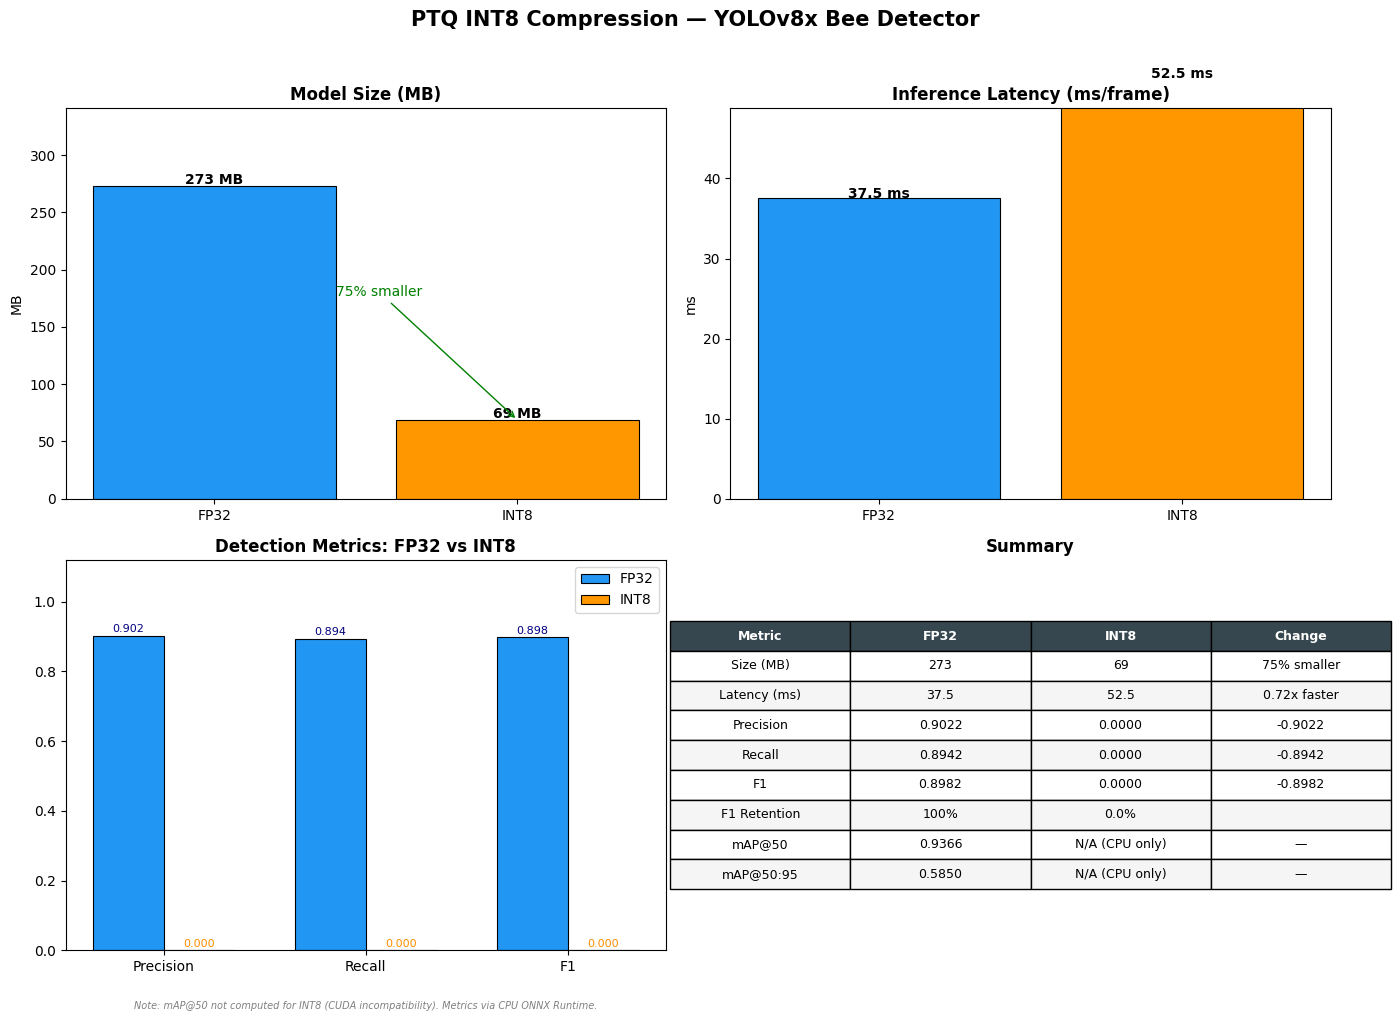

Chart saved.


In [17]:
# ====================
# STEP 6: CHARTS (4 panels)
# ====================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('PTQ INT8 Compression — YOLOv8x Bee Detector',
             fontsize=15, fontweight='bold', y=1.01)
C = ['#2196F3','#FF9800']

# 1: Size
ax = axes[0,0]
br = ax.bar(['FP32','INT8'],[fp32_mb,int8_mb],color=C,edgecolor='k',linewidth=0.8)
ax.set_title('Model Size (MB)',fontweight='bold'); ax.set_ylabel('MB')
ax.set_ylim(0,fp32_mb*1.25)
for b,v2 in zip(br,[fp32_mb,int8_mb]):
    ax.text(b.get_x()+b.get_width()/2, v2+2, f'{v2:.0f} MB', ha='center', fontweight='bold')
ax.annotate(f'{(1-int8_mb/fp32_mb)*100:.0f}% smaller',
    xy=(1,int8_mb), xytext=(0.4,fp32_mb*0.65),
    arrowprops=dict(arrowstyle='->',color='green'), color='green', fontsize=10)

# 2: Speed
ax = axes[0,1]
br = ax.bar(['FP32','INT8'],[fp32_ms,int8_ms],color=C,edgecolor='k',linewidth=0.8)
ax.set_title('Inference Latency (ms/frame)',fontweight='bold'); ax.set_ylabel('ms')
ax.set_ylim(0,fp32_ms*1.3)
for b,v2 in zip(br,[fp32_ms,int8_ms]):
    ax.text(b.get_x()+b.get_width()/2, v2+0.1, f'{v2:.1f} ms', ha='center', fontweight='bold')
ax.annotate(f'{fp32_ms/int8_ms:.2f}x faster',
    xy=(1,int8_ms), xytext=(0.4,fp32_ms*0.65),
    arrowprops=dict(arrowstyle='->',color='green'), color='green', fontsize=10)

# 3: Metrics grouped bar
ax = axes[1,0]
mn = ['Precision','Recall','F1']
fv = [BASELINE['precision'], BASELINE['recall'], BASELINE['f1']]
iv = [res['precision'],       res['recall'],      res['f1']]
x = np.arange(len(mn)); w = 0.35
ax.bar(x-w/2, fv, w, label='FP32', color=C[0], edgecolor='k', linewidth=0.8)
ax.bar(x+w/2, iv, w, label='INT8', color=C[1], edgecolor='k', linewidth=0.8)
ax.set_title('Detection Metrics: FP32 vs INT8', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(mn); ax.set_ylim(0, 1.12); ax.legend()
for xi,(f2,i2) in enumerate(zip(fv,iv)):
    ax.text(xi-w/2, f2+0.01, f'{f2:.3f}', ha='center', fontsize=8, color='navy')
    ax.text(xi+w/2, i2+0.01, f'{i2:.3f}', ha='center', fontsize=8, color='darkorange')
ax.text(0.5, -0.15,
    'Note: mAP@50 not computed for INT8 (CUDA incompatibility). Metrics via CPU ONNX Runtime.',
    ha='center', transform=ax.transAxes, fontsize=7, color='gray', style='italic')

# 4: Summary table
ax = axes[1,1]; ax.axis('off')
rows = [
    ['Size (MB)',     f'{fp32_mb:.0f}',           f'{int8_mb:.0f}',          f'{(1-int8_mb/fp32_mb)*100:.0f}% smaller'],
    ['Latency (ms)',  f'{fp32_ms:.1f}',            f'{int8_ms:.1f}',          f'{fp32_ms/int8_ms:.2f}x faster'],
    ['Precision',     f'{BASELINE["precision"]:.4f}', f'{res["precision"]:.4f}', f'{res["precision"]-BASELINE["precision"]:+.4f}'],
    ['Recall',        f'{BASELINE["recall"]:.4f}',    f'{res["recall"]:.4f}',    f'{res["recall"]-BASELINE["recall"]:+.4f}'],
    ['F1',            f'{BASELINE["f1"]:.4f}',        f'{res["f1"]:.4f}',        f'{res["f1"]-BASELINE["f1"]:+.4f}'],
    ['F1 Retention',  '100%',                        f'{metrics_out["f1_retention_pct"]}%', ''],
    ['mAP@50',        f'{BASELINE["mAP50"]:.4f}',    'N/A (CPU only)',           '—'],
    ['mAP@50:95',     f'{BASELINE["mAP5095"]:.4f}',  'N/A (CPU only)',           '—'],
]
t = ax.table(cellText=rows, colLabels=['Metric','FP32','INT8','Change'],
             loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1.2, 1.6)
for (r,c),cell in t.get_celld().items():
    if r == 0:
        cell.set_facecolor('#37474F')
        cell.set_text_props(color='white', fontweight='bold')
    elif r % 2 == 0:
        cell.set_facecolor('#F5F5F5')
ax.set_title('Summary', fontweight='bold')

plt.tight_layout()
fig.savefig(OUT_DIR/'ptq_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved.')

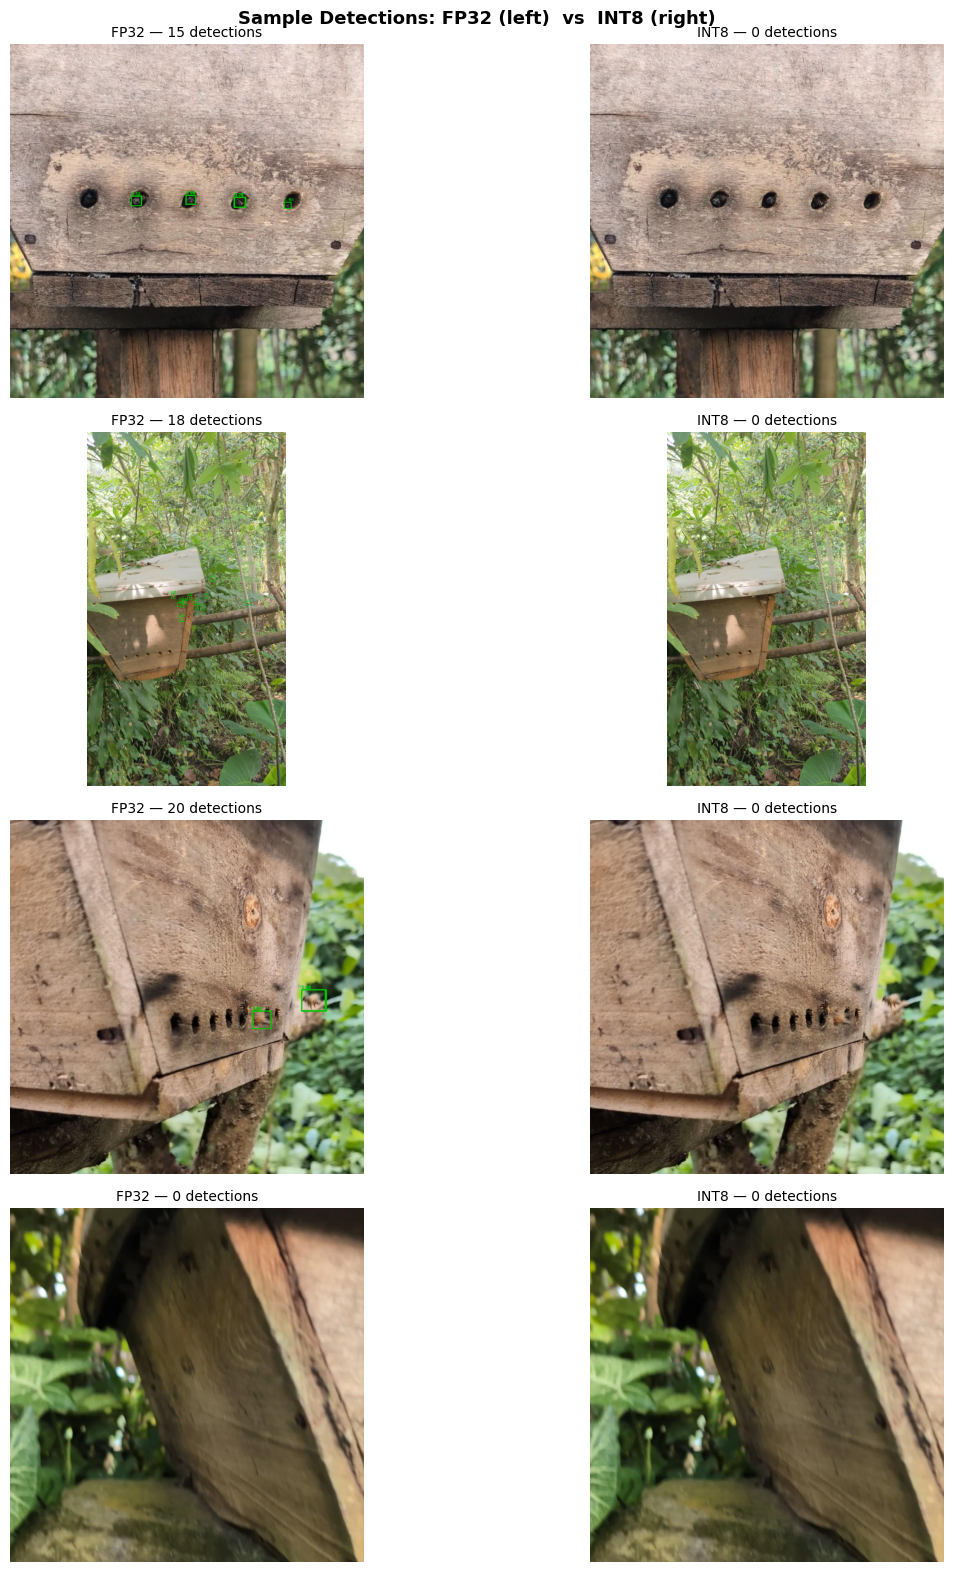

Detection samples saved.


In [19]:
# ====================
# STEP 7: SAMPLE DETECTIONS — FP32 vs INT8 side by side
# Uses ONNX Runtime directly (CPU) — avoids CUDA kernel incompatibility
# ====================

def detect_onnx(model_path, img_path, conf_thresh=0.417, providers=None):
    """Run ONNX model inference, return annotated RGB image and detection count."""
    if providers is None:
        providers = ['CPUExecutionProvider']

    sess   = onnxruntime.InferenceSession(model_path, providers=providers)
    inp_nm = sess.get_inputs()[0].name

    img = cv2.imread(img_path)
    h0, w0 = img.shape[:2]

    # Preprocess
    inp = cv2.resize(img, (640, 640))
    inp = cv2.cvtColor(inp, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    inp = np.expand_dims(np.transpose(inp, (2, 0, 1)), 0)

    out   = sess.run(None, {inp_nm: inp})[0]   # (1, 5, 8400)
    preds = out[0].T                            # (8400, 5): cx,cy,w,h,conf

    # Filter by confidence
    mask  = preds[:, 4] >= conf_thresh
    preds = preds[mask]

    frame = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    count = 0

    for p in preds:
        cx, cy, w, h, conf = p
        x1 = int((cx - w/2) / 640 * w0)
        y1 = int((cy - h/2) / 640 * h0)
        x2 = int((cx + w/2) / 640 * w0)
        y2 = int((cy + h/2) / 640 * h0)
        count += 1
        return_color = (0, 200, 0)  # set per model below
        cv2.rectangle(frame, (x1, y1), (x2, y2), return_color, 2)
        cv2.putText(frame, f'{conf:.2f}', (x1, max(y1-4, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, return_color, 1)

    return frame, count


def detect_onnx_colored(model_path, img_path, conf_thresh, color, providers=None):
    """Same as detect_onnx but with configurable box colour."""
    if providers is None:
        providers = ['CPUExecutionProvider']

    sess   = onnxruntime.InferenceSession(model_path, providers=providers)
    inp_nm = sess.get_inputs()[0].name

    img = cv2.imread(img_path)
    h0, w0 = img.shape[:2]

    inp = cv2.resize(img, (640, 640))
    inp = cv2.cvtColor(inp, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    inp = np.expand_dims(np.transpose(inp, (2, 0, 1)), 0)

    out   = sess.run(None, {inp_nm: inp})[0]
    preds = out[0].T
    mask  = preds[:, 4] >= conf_thresh
    preds = preds[mask]

    frame = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    count = len(preds)

    for p in preds:
        cx, cy, w, h, conf = p
        x1 = int((cx - w/2) / 640 * w0)
        y1 = int((cy - h/2) / 640 * h0)
        x2 = int((cx + w/2) / 640 * w0)
        y2 = int((cy + h/2) / 640 * h0)
        cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)
        cv2.putText(frame, f'{conf:.2f}', (x1, max(y1-4, 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

    return frame, count


sample_imgs = list(Path(VAL_IMGS).glob('*.jpg'))[:4]

fig, axes = plt.subplots(len(sample_imgs), 2, figsize=(14, 4 * len(sample_imgs)))
fig.suptitle('Sample Detections: FP32 (left)  vs  INT8 (right)',
             fontsize=13, fontweight='bold')

models = [
    (fp32_onnx, 'FP32', (0, 200, 0)),
    (int8_onnx, 'INT8', (255, 140, 0)),
]

for row, ip in enumerate(sample_imgs):
    for col, (mpath, lbl, clr) in enumerate(models):
        frame, count = detect_onnx_colored(mpath, str(ip), CONF_THRESH, clr)
        axes[row, col].imshow(frame)
        axes[row, col].set_title(f'{lbl} — {count} detections', fontsize=10)
        axes[row, col].axis('off')

plt.tight_layout()
fig.savefig(OUT_DIR / 'sample_detections.png', dpi=120, bbox_inches='tight')
plt.show()
print('Detection samples saved.')

In [21]:
# ====================
# STEP 8: ZIP ALL ARTIFACTS
# Download: Kaggle Output tab -> ptq_int8_artifacts.zip
# ====================
zip_path = '/kaggle/working/ptq_int8_artifacts.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in OUT_DIR.rglob('*'):
        if f.is_file(): zf.write(f, f.relative_to(OUT_DIR))

print('=== ARTIFACTS ZIPPED ===')
print(f'File: {zip_path}  ({os.path.getsize(zip_path)/1e6:.1f} MB)')
print('Contents:')
with zipfile.ZipFile(zip_path) as zf:
    for n in sorted(zf.namelist()):
        print(f'  {n:<45} {zf.getinfo(n).file_size/1e6:.1f} MB')
print('\nDownload from the Kaggle Output tab.')

=== ARTIFACTS ZIPPED ===
File: /kaggle/working/ptq_int8_artifacts.zip  (267.5 MB)
Contents:
  best_fp32.onnx                                272.8 MB
  best_int8.onnx                                68.7 MB
  ptq_metrics.json                              0.0 MB
  ptq_results.png                               0.2 MB
  sample_detections.png                         1.2 MB

Download from the Kaggle Output tab.
